In [1]:
# =========================
# 0) Montar Drive + configurar proyecto (SETUP ÚNICO)
# =========================

from google.colab import drive 
drive.mount('/content/drive')

import os, sys

# Detecta la ruta exista (con o sin espacio)
CANDIDATAS = [
    "/content/drive/MyDrive/Colab_Notebooks/Parcial1_MBA",
    "/content/drive/MyDrive/Colab Notebooks/Parcial1_MBA",
]

RUTA_PROYECTO = next((p for p in CANDIDATAS if os.path.exists(p)), None)
assert RUTA_PROYECTO is not None, "❌ No encuentro Parcial1_MBA en Drive. Revisa tu ruta."

# Nos movemos al root para trabajar con rutas relativas
os.chdir(RUTA_PROYECTO)

# Asegura carpetas
for carpeta in ["motor", "universidad", "trafico", "figuras"]:
    os.makedirs(carpeta, exist_ok=True)

# Asegura __init__.py válidos (para imports)
for p in ["motor/__init__.py", "universidad/__init__.py", "trafico/__init__.py"]:
    with open(p, "w", encoding="utf-8") as f:
        f.write("# package init\n")

# Habilita imports desde el proyecto
if RUTA_PROYECTO not in sys.path:
    sys.path.insert(0, RUTA_PROYECTO)

print("✅ Ruta proyecto:", RUTA_PROYECTO)
print("✅ Contenido raíz:", os.listdir("."))

# =========================
# Verificación (Colab)
# =========================
# Si los módulos de tráfico fueran JSON de notebook, los imports fallan.
# Ya no auto-reparamos aquí; solo verificamos y damos un error claro.

def _verificar_py_no_json(ruta: str) -> None:
    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No existe {ruta}. Revisa tu Drive / ruta de proyecto.")
    with open(ruta, "r", encoding="utf-8") as f:
        cabeza = f.read(400).lstrip()
    if cabeza.startswith("{") and '"nbformat"' in cabeza[:200]:
        raise AssertionError(
            f"{ruta} parece un notebook JSON. Debe ser un archivo .py. "
            f"Reemplázalo por el módulo Python correcto."
        )

for _ruta in [
    "trafico/luces_trafico.py",
    "trafico/agentes_trafico.py",
    "trafico/sim_trafico.py",
    "trafico/metricas_trafico.py",
]:
    _verificar_py_no_json(_ruta)

print("✅ Módulos de tráfico verificados.")

Mounted at /content/drive
✅ Ruta proyecto: /content/drive/MyDrive/Colab_Notebooks/Parcial1_MBA
✅ Contenido raíz: ['motor', 'universidad', 'trafico', 'figuras', 'Copia de Entregable_Parcial_MBA.ipynb', 'Entregable_Parcial_MBA.ipynb']
✅ Módulos de tráfico verificados.


In [2]:
# =========================
# 1) Imports
# =========================

from motor.grid import MundoCuadricula, TipoCelda
from motor.sim_base import SimulacionBase, AgenteBase
from motor.viz import dibujar_cuadricula, dibujar_agentes

from universidad.sim_uni import SimulacionUniversidad

# Nota Colab: si editas un .py y re-ejecutas imports sin reiniciar runtime,
# Python puede usar el módulo cacheado. Forzamos recarga para evitar ImportError.
import importlib

import universidad.metricas_uni as _mu
importlib.reload(_mu)

resumen_porcentaje_tiempo_por_zona = _mu.resumen_porcentaje_tiempo_por_zona

graficar_ocupacion = _mu.graficar_ocupacion

# Fallbacks: si tu Drive aún tiene una versión vieja del archivo, el notebook no revienta.
primeros_eventos = getattr(_mu, "primeros_eventos", lambda eventos, n=20: list(eventos[:n]))
ultimos_eventos = getattr(_mu, "ultimos_eventos", lambda eventos, n=20: list(eventos[-n:]) if len(eventos) >= n else list(eventos))

def _filtrar_fallback(eventos, id_estudiante):
    marca = f"Estudiante {id_estudiante} "
    return [e for e in eventos if marca in e]

filtrar_eventos_por_estudiante = getattr(_mu, "filtrar_eventos_por_estudiante", _filtrar_fallback)

import trafico.sim_trafico as _st
importlib.reload(_st)
SimulacionTrafico = _st.SimulacionTrafico
crear_mapa_trafico = _st.crear_mapa_trafico

import trafico.metricas_trafico as _mt
importlib.reload(_mt)

tiempo_espera_promedio = _mt.tiempo_espera_promedio
flujo_total = _mt.flujo_total
graficar_cola_y_flujo = _mt.graficar_cola_y_flujo
graficar_mapa_con_accidente = getattr(_mt, "graficar_mapa_con_accidente", lambda s: None)
graficar_estado_trafico = getattr(_mt, "graficar_estado_trafico", graficar_mapa_con_accidente)
resumen_accidentes = getattr(_mt, "resumen_accidentes", lambda s: {})

print("✅ Imports listos.")

✅ Imports listos.


In [3]:
# (Opcional) Celda redundante eliminada: los imports están en la celda 1.
# Si trabajas en Colab, la celda 0 ya añade RUTA_PROYECTO a sys.path.
pass

In [10]:
# =========================
# Parámetros globales (semillas, probabilidades)
# =========================
SEMILLA_UNI = 777
SEMILLA_TRAFICO = 449
PASOS_UNI = 200
MAX_TICKS = 150
PASOS_TRAFICO = MAX_TICKS
P_PASARSE_AMARILLO = 0.03
P_PASARSE_ROJO = 0.003
# Animación: False por defecto para "Run all" rápido
ANIMAR = True
SNAPSHOTS_CADA_N = 10  # cada cuántos ticks mostrar snapshot (si ANIMAR)

In [ ]:
# =========================
# Panel de control — ejecutar sin editar celdas (recrea todo desde cero)
# =========================
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    import matplotlib.pyplot as plt
    output_resultados = widgets.Output()
    output_eventos = widgets.Output()
    ultimo_sim_uni, ultimo_sim_traf = None, None
    def construir_selector_eventos(sim, titulo="Eventos", maxN=100, tipo="uni"):
        ev = getattr(sim, "eventos", [])
        out_ev = widgets.Output()
        modo = widgets.Dropdown(options=[("Primeros N", "primeros"), ("Últimos N", "ultimos"), ("Por agente", "agente")], value="primeros", description="Ver:")
        n_slider = widgets.IntSlider(value=min(20, maxN), min=1, max=maxN, description="N:")
        if tipo == "uni" and hasattr(sim, "agentes"):
            ids = [(str(i), i) for i in range(len(sim.agentes))]
        else:
            ids = []
            for e in ev:
                s = str(e)
                if s.strip().startswith("Veh ") and len(s) > 4:
                    try:
                        vid = int(s[4:].strip().split()[0])
                        if not any(x[1] == vid for x in ids):
                            ids.append((str(vid), vid))
                    except (ValueError, IndexError):
                        pass
            ids = sorted(ids, key=lambda x: x[1]) if ids else [(str(0), 0)]
        id_agente = widgets.Dropdown(options=ids, description="ID agente:" if tipo == "uni" else "ID veh:", disabled=True)
        def on_modo(change):
            id_agente.disabled = (change.new != "agente")
        modo.observe(on_modo, names="value")
        def filtrar_traf(evs, vid):
            return [e for e in evs if ("Veh " + str(vid) + " ") in str(e) or ("Veh " + str(vid) + "(") in str(e)]
        def _mostrar(b):
            with out_ev:
                clear_output(wait=True)
                if modo.value == "primeros":
                    for e in primeros_eventos(ev, n=n_slider.value):
                        print(e)
                elif modo.value == "ultimos":
                    for e in ultimos_eventos(ev, n=n_slider.value):
                        print(e)
                else:
                    if tipo == "uni":
                        for e in filtrar_eventos_por_estudiante(ev, id_agente.value):
                            print(e)
                    else:
                        for e in filtrar_traf(ev, id_agente.value):
                            print(e)
        btn = widgets.Button(description="Mostrar")
        btn.on_click(_mostrar)
        return widgets.VBox([widgets.HTML("<b>" + titulo + "</b>"), widgets.HBox([modo, n_slider, id_agente]), btn, out_ev])
    _modo = widgets.Dropdown(options=[("Universidad", "uni"), ("Tráfico", "trafico"), ("Ambos", "ambos")], value="ambos", description="Modo:")
    _s_uni = widgets.IntText(value=SEMILLA_UNI, description="Semilla Uni:")
    _s_traf = widgets.IntText(value=SEMILLA_TRAFICO, description="Semilla Tráf:")
    _pasos_uni = widgets.IntText(value=PASOS_UNI, description="Pasos Uni:")
    _max_ticks = widgets.IntText(value=MAX_TICKS, description="Max ticks Tráf:")
    _p_amarillo = widgets.FloatText(value=P_PASARSE_AMARILLO, description="p_amarillo:")
    _p_rojo = widgets.FloatText(value=P_PASARSE_ROJO, description="p_rojo:")
    _p_spawn = widgets.FloatText(value=0.25, description="p_spawn:")
    _max_veh = widgets.IntText(value=40, description="max_veh:")
    _mostrar_resultados = widgets.Checkbox(value=True, description="Mostrar resultados")
    _animar = widgets.Checkbox(value=False, description="Animar")
    _mostrar_eventos = widgets.Checkbox(value=False, description="Mostrar eventos")
    def _ejecutar(b):
        global entorno_uni, sim_uni, entorno_trafico, spawns_trafico, sim_trafico, ultimo_sim_uni, ultimo_sim_traf
        modo = _modo.value
        with output_resultados:
            clear_output(wait=True)
            if modo in ("uni", "ambos"):
                entorno_uni = MundoCuadricula(ancho=30, alto=20)
                entorno_uni.rellenar_rectangulo(2, 2, 16, 10, TipoCelda.AULA)
                entorno_uni.rellenar_rectangulo(20, 2, 8, 8, TipoCelda.BIBLIOTECA)
                entorno_uni.rellenar_rectangulo(20, 12, 8, 6, TipoCelda.CAFETERIA)
                sim_uni = SimulacionUniversidad(entorno=entorno_uni, n_estudiantes=25, semilla=_s_uni.value,
                    cap_aula=20, cap_biblio=15, cap_cafe=10, umbral_aula=18, p_volver_aula=0.10,
                    enfriamiento_mov=2, p_ir_cafeteria=0.30)
                if _animar.value:
                    steps_anim_uni = min(80, _pasos_uni.value)
                    for _ in range(steps_anim_uni):
                        sim_uni.paso()
                        sim_uni.tiempo += 1
                        if sim_uni.tiempo % SNAPSHOTS_CADA_N == 0:
                            clear_output(wait=True)
                            fig, ax = plt.subplots(figsize=(7, 5))
                            dibujar_cuadricula(ax, sim_uni.entorno.terreno)
                            posiciones = [sim_uni.entorno.obtener_posicion_agente(aid) for aid in sim_uni.agentes]
                            dibujar_agentes(ax, posiciones)
                            ax.set_title("Universidad t=" + str(sim_uni.tiempo))
                            plt.show()
                            plt.pause(0.05)
                    for _ in range(steps_anim_uni, _pasos_uni.value):
                        sim_uni.paso()
                        sim_uni.tiempo += 1
                else:
                    sim_uni.ejecutar(pasos=_pasos_uni.value, verificar_cada=10)
                ultimo_sim_uni = sim_uni
                if _mostrar_resultados.value:
                    print("✅ Universidad terminada. Tiempo por zona (%):", resumen_porcentaje_tiempo_por_zona(sim_uni.agentes))
                    graficar_ocupacion(sim_uni.metricas)
                    plt.show()
            if modo in ("trafico", "ambos"):
                entorno_trafico, spawns_trafico = crear_mapa_trafico(ancho=25, alto=25, ancho_via=3, tam_interseccion=5)
                sim_trafico = SimulacionTrafico(entorno=entorno_trafico, semilla=_s_traf.value, max_vehiculos=_max_veh.value,
                    p_pasarse_amarillo=_p_amarillo.value, p_pasarse_rojo=_p_rojo.value, p_spawn=_p_spawn.value,
                    spawns_por_direccion=spawns_trafico)
                if _animar.value:
                    steps_anim_traf = min(100, _max_ticks.value)
                    steps_hechos = 0
                    for _ in range(steps_anim_traf):
                        if sim_trafico.detener:
                            break
                        sim_trafico.paso()
                        sim_trafico.tiempo += 1
                        steps_hechos += 1
                        if sim_trafico.tiempo % SNAPSHOTS_CADA_N == 0 or sim_trafico.hubo_accidente:
                            clear_output(wait=True)
                            graficar_estado_trafico(sim_trafico)
                            plt.show()
                            if sim_trafico.hubo_accidente:
                                plt.pause(2)
                                break
                            plt.pause(0.05)
                    for _ in range(steps_hechos, _max_ticks.value):
                        if sim_trafico.detener:
                            break
                        sim_trafico.paso()
                        sim_trafico.tiempo += 1
                else:
                    sim_trafico.ejecutar(pasos=_max_ticks.value, verificar_cada=10)
                ultimo_sim_traf = sim_trafico
                if _mostrar_resultados.value:
                    print("✅ Tráfico terminado. Salidos:", sim_trafico.vehiculos_salidos)
                    graficar_cola_y_flujo(sim_trafico.cola_por_tick, sim_trafico.flujo_por_tick)
                    plt.show()
                    graficar_estado_trafico(sim_trafico)
                    plt.show()
                    if sim_trafico.hubo_accidente:
                        print("⚠️ Accidente tick", sim_trafico.tick_accidente, "|", sim_trafico.info_accidente.get("tipo_violacion", "?"))
        with output_eventos:
            clear_output(wait=True)
            if _mostrar_eventos.value:
                if modo == "uni" and ultimo_sim_uni is not None:
                    display(construir_selector_eventos(ultimo_sim_uni, titulo="Eventos Universidad", maxN=100, tipo="uni"))
                elif modo == "trafico" and ultimo_sim_traf is not None:
                    display(construir_selector_eventos(ultimo_sim_traf, titulo="Eventos Tráfico", maxN=100, tipo="traf"))
                elif modo == "ambos":
                    if ultimo_sim_uni is not None:
                        display(construir_selector_eventos(ultimo_sim_uni, titulo="Eventos Universidad", maxN=100, tipo="uni"))
                    if ultimo_sim_traf is not None:
                        display(construir_selector_eventos(ultimo_sim_traf, titulo="Eventos Tráfico", maxN=100, tipo="traf"))
    _btn = widgets.Button(description="Ejecutar")
    _btn.on_click(_ejecutar)
    display(widgets.VBox([widgets.HBox([_modo, _s_uni, _s_traf, _pasos_uni, _max_ticks]),
                          widgets.HBox([_p_amarillo, _p_rojo, _p_spawn, _max_veh]),
                          widgets.HBox([_mostrar_resultados, _animar, _mostrar_eventos, _btn]),
                          widgets.HTML("<b>Resultados / gráficas</b>"), output_resultados,
                          widgets.HTML("<b>Selector de eventos</b>"), output_eventos]))
except Exception as e:
    print("Panel de control (ipywidgets):", e)
    try:
        if _mostrar_eventos and ultimo_sim_uni is not None:
            for e in ultimos_eventos(getattr(ultimo_sim_uni, "eventos", []), n=20):
                print(e)
        if _mostrar_eventos and ultimo_sim_traf is not None:
            for e in ultimos_eventos(getattr(ultimo_sim_traf, "eventos", []), n=20):
                print(e)
    except NameError:
        pass

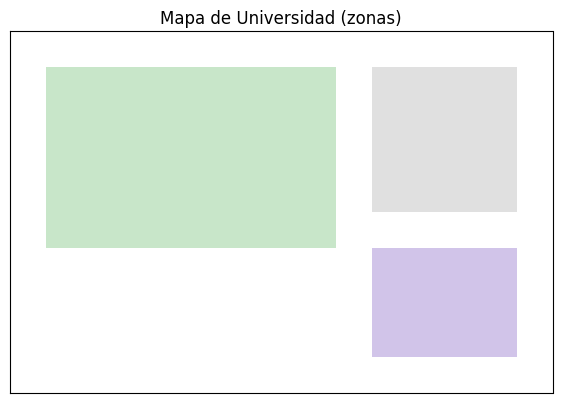

In [11]:
# =========================
# 2) Crear mapa de Universidad (Matriz / Grid)
# =========================

import matplotlib.pyplot as plt

entorno_uni = MundoCuadricula(ancho=30, alto=20)

# Aula (bloque grande)
entorno_uni.rellenar_rectangulo(x0=2, y0=2, w=16, h=10, tipo_celda=TipoCelda.AULA)

# Biblioteca (bloque mediano)
entorno_uni.rellenar_rectangulo(x0=20, y0=2, w=8, h=8, tipo_celda=TipoCelda.BIBLIOTECA)

# Cafetería (bloque pequeño)
entorno_uni.rellenar_rectangulo(x0=20, y0=12, w=8, h=6, tipo_celda=TipoCelda.CAFETERIA)

fig, ax = plt.subplots(figsize=(7, 5))
dibujar_cuadricula(ax, entorno_uni.terreno)
plt.title("Mapa de Universidad (zonas)")
plt.show()

✅ Simulación Universidad terminada.
Distribución promedio de tiempo (%): {'aula': 56.94, 'biblioteca': 6.18, 'cafeteria': 36.88}


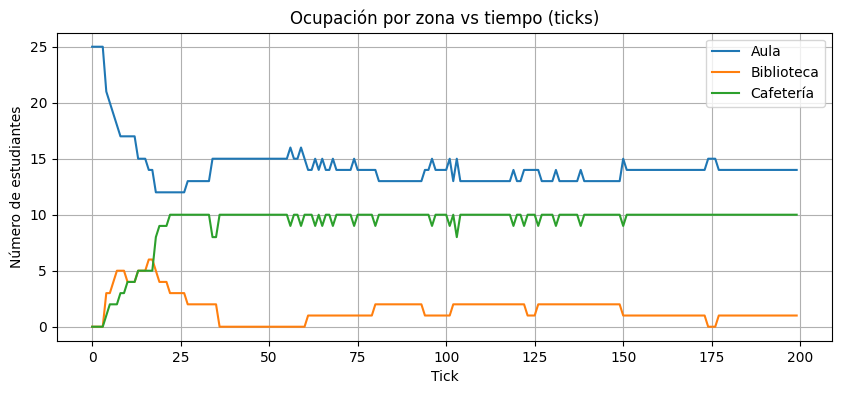

In [12]:
# =========================
# 3) Ejecutar simulación MBA Universidad
# =========================

sim_uni = SimulacionUniversidad(
    entorno=entorno_uni,
    n_estudiantes=25,
    semilla=SEMILLA_UNI,
    cap_aula=20,
    cap_biblio=15,
    cap_cafe=10,
    umbral_aula=18,
    p_volver_aula=0.10,
    enfriamiento_mov=2,
    p_ir_cafeteria=0.30
)

sim_uni.ejecutar(pasos=PASOS_UNI, verificar_cada=10)

print("✅ Simulación Universidad terminada.")
print("Distribución promedio de tiempo (%):", resumen_porcentaje_tiempo_por_zona(sim_uni.agentes))

graficar_ocupacion(sim_uni.metricas)

In [13]:
# =========================
# (Opcional) Selector UI para eventos Universidad — sin spam; mostrar solo al pulsar
# =========================
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    _eventos_out = widgets.Output()
    _modo = widgets.Dropdown(options=[("Primeros N", "primeros"), ("Últimos N", "ultimos"), ("Por agente", "agente")], value="primeros", description="Ver:")
    _n = widgets.IntSlider(value=20, min=1, max=100, description="N:")
    _id_agente = widgets.Dropdown(options=[(str(i), i) for i in range(len(sim_uni.agentes))], description="ID agente:", disabled=True)
    def _on_modo(change):
        _id_agente.disabled = (change.new != "agente")
    _modo.observe(_on_modo, names="value")
    def _mostrar(b):
        with _eventos_out:
            clear_output(wait=True)
            ev = getattr(sim_uni, "eventos", [])
            if _modo.value == "primeros":
                for e in primeros_eventos(ev, n=_n.value):
                    print(e)
            elif _modo.value == "ultimos":
                for e in ultimos_eventos(ev, n=_n.value):
                    print(e)
            else:
                for e in filtrar_eventos_por_estudiante(ev, _id_agente.value):
                    print(e)
    _btn = widgets.Button(description="Mostrar")
    _btn.on_click(_mostrar)
    display(widgets.VBox([widgets.HBox([_modo, _n, _id_agente]), _btn, _eventos_out]))
except Exception as e:
    print("Para selector de eventos instala ipywidgets. Fallback: primeros 20.")
    for e in primeros_eventos(getattr(sim_uni, "eventos", []), n=20):
        print(e)

In [ ]:
# Listado de módulos del proyecto (para sustentación)
import os
archivos = [
    "motor/grid.py", "motor/sim_base.py", "motor/viz.py",
    "universidad/agentes_uni.py", "universidad/sim_uni.py", "universidad/metricas_uni.py",
    "trafico/luces_trafico.py", "trafico/agentes_trafico.py", "trafico/sim_trafico.py", "trafico/metricas_trafico.py",
]
for ruta in archivos:
    existe = "✅" if os.path.exists(ruta) else "❌"
    print(f"{existe} {ruta}")

In [ ]:
print("Celdas cafetería:", len(entorno_uni.celdas_de_tipo(TipoCelda.CAFETERIA)))
print("Celdas biblioteca:", len(entorno_uni.celdas_de_tipo(TipoCelda.BIBLIOTECA)))
print("Celdas aula:", len(entorno_uni.celdas_de_tipo(TipoCelda.AULA)))

In [ ]:
# =========================
# (Opcional) Animación Universidad — ANIMAR=False por defecto
# =========================
if ANIMAR:
    from IPython.display import clear_output
    sim_anim = SimulacionUniversidad(entorno=entorno_uni, n_estudiantes=25, semilla=SEMILLA_UNI,
        cap_aula=20, cap_biblio=15, cap_cafe=10, umbral_aula=18, p_volver_aula=0.10,
        enfriamiento_mov=2, p_ir_cafeteria=0.30)
    for _ in range(min(80, PASOS_UNI)):
        sim_anim.paso()
        sim_anim.tiempo += 1
        if sim_anim.tiempo % SNAPSHOTS_CADA_N == 0:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(7, 5))
            dibujar_cuadricula(ax, sim_anim.entorno.terreno)
            posiciones = [sim_anim.entorno.obtener_posicion_agente(aid) for aid in sim_anim.agentes]
            dibujar_agentes(ax, posiciones)
            ax.set_title(f"Universidad t={sim_anim.tiempo}")
            plt.show()
            plt.pause(0.05)

In [ ]:
# --- Fin sección Universidad. Siguiente: MBA Tráfico ---
pass

## MBA Tráfico — Mapa y simulación
Mapa de vías e intersección; semáforos con una sola fase en verde a la vez.

In [ ]:
# Crear mapa de Tráfico (fondo VACÍO + cruz de vías + intersección)
import matplotlib.pyplot as plt
entorno_trafico, spawns_trafico = crear_mapa_trafico(ancho=25, alto=25, ancho_via=3, tam_interseccion=5)
fig, ax = plt.subplots(figsize=(6, 6))
dibujar_cuadricula(ax, entorno_trafico.terreno)
plt.title("Mapa de Tráfico (vías e intersección)")
plt.show()

In [ ]:
# Ejecutar simulación MBA Tráfico (misma semilla = reproducible)
sim_trafico = SimulacionTrafico(
    entorno=entorno_trafico,
    semilla=SEMILLA_TRAFICO,
    ticks_verde=5,
    ticks_amarillo=2,
    ticks_todo_rojo=1,
    p_spawn=0.25,
    max_vehiculos=40,
    p_pasarse_amarillo=P_PASARSE_AMARILLO,
    p_pasarse_rojo=P_PASARSE_ROJO,
    spawns_por_direccion=spawns_trafico,
)
sim_trafico.ejecutar(pasos=MAX_TICKS, verificar_cada=10)
print("✅ Simulación Tráfico terminada.")
print("Vehículos que salieron:", sim_trafico.vehiculos_salidos)
print("Tiempo de espera promedio (ticks):", tiempo_espera_promedio(sim_trafico.tiempos_espera_salidos))
print("Flujo total:", flujo_total(sim_trafico.flujo_por_tick))
if sim_trafico.hubo_accidente:
    print("⚠️ Accidente en tick", sim_trafico.tick_accidente, "| tipo violación:", sim_trafico.info_accidente.get("tipo_violacion", "?"))
    print("Pasos en rojo:", sim_trafico.contador_pasos_en_rojo, "en amarillo:", sim_trafico.contador_pasos_en_amarillo)
else:
    print("Sin accidente (simulación terminó por MAX_TICKS =", MAX_TICKS, ")")

In [ ]:
# Métricas Tráfico: cola y flujo por tick
graficar_cola_y_flujo(
    sim_trafico.cola_por_tick,
    sim_trafico.flujo_por_tick,
)
# Estado final: mapa con vías, vehículos y título (tick, semáforo, cola, throughput, accidente si aplica)
graficar_estado_trafico(sim_trafico)
plt.show()

In [ ]:
# (Opcional) Eventos Tráfico: primeros y últimos
for e in sim_trafico.eventos[:15]:
    print(e)
print("...")
for e in sim_trafico.eventos[-10:]:
    print(e)

In [ ]:
# =========================
# (Opcional) Animación Tráfico — ANIMAR=False por defecto; si accidente muestra X
# =========================
if ANIMAR:
    from IPython.display import clear_output
    sim_anim_t = SimulacionTrafico(entorno=entorno_trafico, semilla=SEMILLA_TRAFICO, max_vehiculos=40,
        ticks_verde=5, ticks_amarillo=2, ticks_todo_rojo=1, p_pasarse_amarillo=P_PASARSE_AMARILLO, p_pasarse_rojo=P_PASARSE_ROJO,
        spawns_por_direccion=spawns_trafico)
    for _ in range(min(100, PASOS_TRAFICO)):
        if sim_anim_t.detener:
            break
        sim_anim_t.paso()
        sim_anim_t.tiempo += 1
        if sim_anim_t.tiempo % SNAPSHOTS_CADA_N == 0 or sim_anim_t.hubo_accidente:
            clear_output(wait=True)
            graficar_estado_trafico(sim_anim_t)
            plt.show()
            if sim_anim_t.hubo_accidente:
                plt.pause(2)
                break
            plt.pause(0.05)